# Example 7: ThermoElectricCurrent + Wishart analysis on molten salt

This example shows a one-shot thermoelectric workflow using `ThermoElectricCurrent`.

We use the molten NaCl dataset already shipped with SporTran and treat:
- `flux` as a prepared heat-like current $j_q$
- `vcm[1]` as a prepared charge-like current $j_c$

The notebook runs Wishart maximum-likelihood analysis and produces plots in the same spirit as the workflow example (raw vs moving-average vs Wishart-filtered curves).

For reference: [Pegolo et al., J. Chem. Phys. 162, 064111 (2025)](https://doi.org/10.1063/5.0249677)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import sportran as st
except ImportError:
    from sys import path

    path.append('..')
    import sportran as st


In [2]:
# 1) Load molten NaCl data
jfile = st.i_o.TableFile('data/NaCl/NaCl.dat', group_vectors=True)
jfile.read_datalines(start_step=0, NSTEPS=0, select_ckeys=['Temp', 'flux', 'vcm[1]'])

DT_FS = 5.0
TEMPERATURE = float(np.mean(jfile.data['Temp']))
VOLUME = 40.21 ** 3

j_q = jfile.data['flux']
j_c = jfile.data['vcm[1]']

print(f'T = {TEMPERATURE:.3f} K')
print(f'V = {VOLUME:.3f} A^3')
print('j_q shape:', j_q.shape)
print('j_c shape:', j_c.shape)

# Molten NaCl - Fumi-Tosi potential
# https://journals.aps.org/prl/supplemental/10.1103/PhysRevLett.122.255901/Bertossa_et_al_Supplemental_Material.pdf
# 1728 atoms, T~1400K
# NVE, dt = 1.0 fs, 100 ps, print_step = 5.0 fs
# Volume = 65013.301261 A^3
# LAMMPS metal units
Temp    c_flux[1] c_flux[2] c_flux[3] c_vcm[1][1] c_vcm[1][2] c_vcm[1][3]
 #####################################
  all_ckeys =  [('Temp', array([0])), ('flux', array([1, 2, 3])), ('vcm[1]', array([4, 5, 6]))]
 #####################################
Data length =  20000
  ckey =  [('Temp', array([0])), ('flux', array([1, 2, 3])), ('vcm[1]', array([4, 5, 6]))]
  ( 20000 ) steps read.
DONE.  Elapsed time:  0.12229013442993164 seconds
T = 1399.348 K
V = 65013.301 A^3
j_q shape: (20000, 3)
j_c shape: (20000, 3)


In [3]:
# 2) Build ThermoElectricCurrent and resample
te = st.ThermoElectricCurrent(
    heat_current=j_q,
    charge_current=j_c,
    DT_FS=DT_FS,
    UNITS='metal',
    TEMPERATURE=TEMPERATURE,
    VOLUME=VOLUME,
    PSD_FILTER_W=0.1,
    FREQ_UNITS='THz',
)

te = te.resample(fstar_THz=14.0, plot=False, freq_units='thz')

Using multicomponent code.
Using multicomponent code.
-----------------------------------------------------
  RESAMPLE TIME SERIES
-----------------------------------------------------
 Original Nyquist freq  f_Ny =     100.00000 THz
 Resampling freq          f* =      14.28571 THz
 Sampling time         TSKIP =             7 steps
                             =        35.000 fs
 Original  n. of frequencies =         10001
 Resampled n. of frequencies =          1429
 PSD      @cutoff  (pre-filter&sample) ~ 443152.37265
                  (post-filter&sample) ~ 564877.86516
 log(PSD) @cutoff  (pre-filter&sample) ~     12.89638
                  (post-filter&sample) ~     13.05597
 min(PSD)          (pre-filter&sample) =      0.31536
 min(PSD)         (post-filter&sample) =  22166.11934
 % of original PSD Power f<f* (pre-filter&sample)  = 96.679 %
-----------------------------------------------------



In [4]:
# 3) One-shot Wishart analysis
result = te.analyze_wishart(
    n_parameters=6,
    mask=(slice(None), slice(None), slice(None, None, 20)),
    minimize_kwargs={
        'tol': 1e-8,
        'jac': '3-point',
        'options': {'disp': False, 'gtol': 1e-4, 'maxiter': 200, 'eps': 1e-6},
    },
    mc_samples=256,
)

print('sigma  = {:.6e} +/- {:.6e} S/m'.format(result.sigma, result.sigma_std))
print('kappa  = {:.6e} +/- {:.6e} W/m/K'.format(result.kappa, result.kappa_std))
print('seebeck= {:.6e} +/- {:.6e} V/K'.format(result.seebeck, result.seebeck_std))

MaxLikeFilter Initialization
Maximum-likelihood estimation with n_parameters = 6
Spline nodes are equispaced from 0 to the Nyquist frequency.
The BFGS solver provides Hessian. Covariance matrix estimated through Laplace approximation.
-----------------------------------------------------
  MAXIMUM LIKELIHOOD ESTIMATION
-----------------------------------------------------
  Fixed n_parameters = 6
  S_{00} =     7573493.881169 +/- 2820613.640671
  S_{01} =       -2066.017890 +/- 1261.181569
  S_{11} =           2.575396 +/-   0.816198
-----------------------------------------------------

sigma  = 2.631620e-04 +/- 8.713063e-05 S/m
kappa  = 4.320056e-01 +/- 1.505364e-01 W/m/K
seebeck= -5.732768e-01 +/- 2.581105e-01 V/K


In [5]:
# 4) Frequency-dependent coefficients from the library API
coef_raw = te.coefficients_vs_frequency(source='raw', units='plot', with_uq=False)
coef_filt = te.coefficients_vs_frequency(source='filtered', units='plot', with_uq=False)
coef_w = te.coefficients_vs_frequency(
    source='wishart',
    units='plot',
    with_uq=True,
    uq='mc',
    mc_samples=256,
)

freq_raw = coef_raw['omega']
freq_fit = coef_w['omega']

sigma_raw, kappa_raw, seeb_raw = coef_raw['sigma'], coef_raw['kappa'], coef_raw['seebeck']
sigma_filt, kappa_filt, seeb_filt = coef_filt['sigma'], coef_filt['kappa'], coef_filt['seebeck']
sigma_fit, kappa_fit, seeb_fit = coef_w['sigma'], coef_w['kappa'], coef_w['seebeck']
sigma_fit_std = coef_w.get('sigma_std', None)
kappa_fit_std = coef_w.get('kappa_std', None)
seeb_fit_std = coef_w.get('seebeck_std', None)

# Keep direct spectral matrix arrays for the first diagnostic panel
raw_S = te.cospectrum.real.transpose((2, 0, 1)) / te.N_EQUIV_COMPONENTS
filt_S = te.fcospectrum.real.transpose((2, 0, 1))
fit_S = result.spectral_matrix_mean
fit_S_std = result.spectral_matrix_std

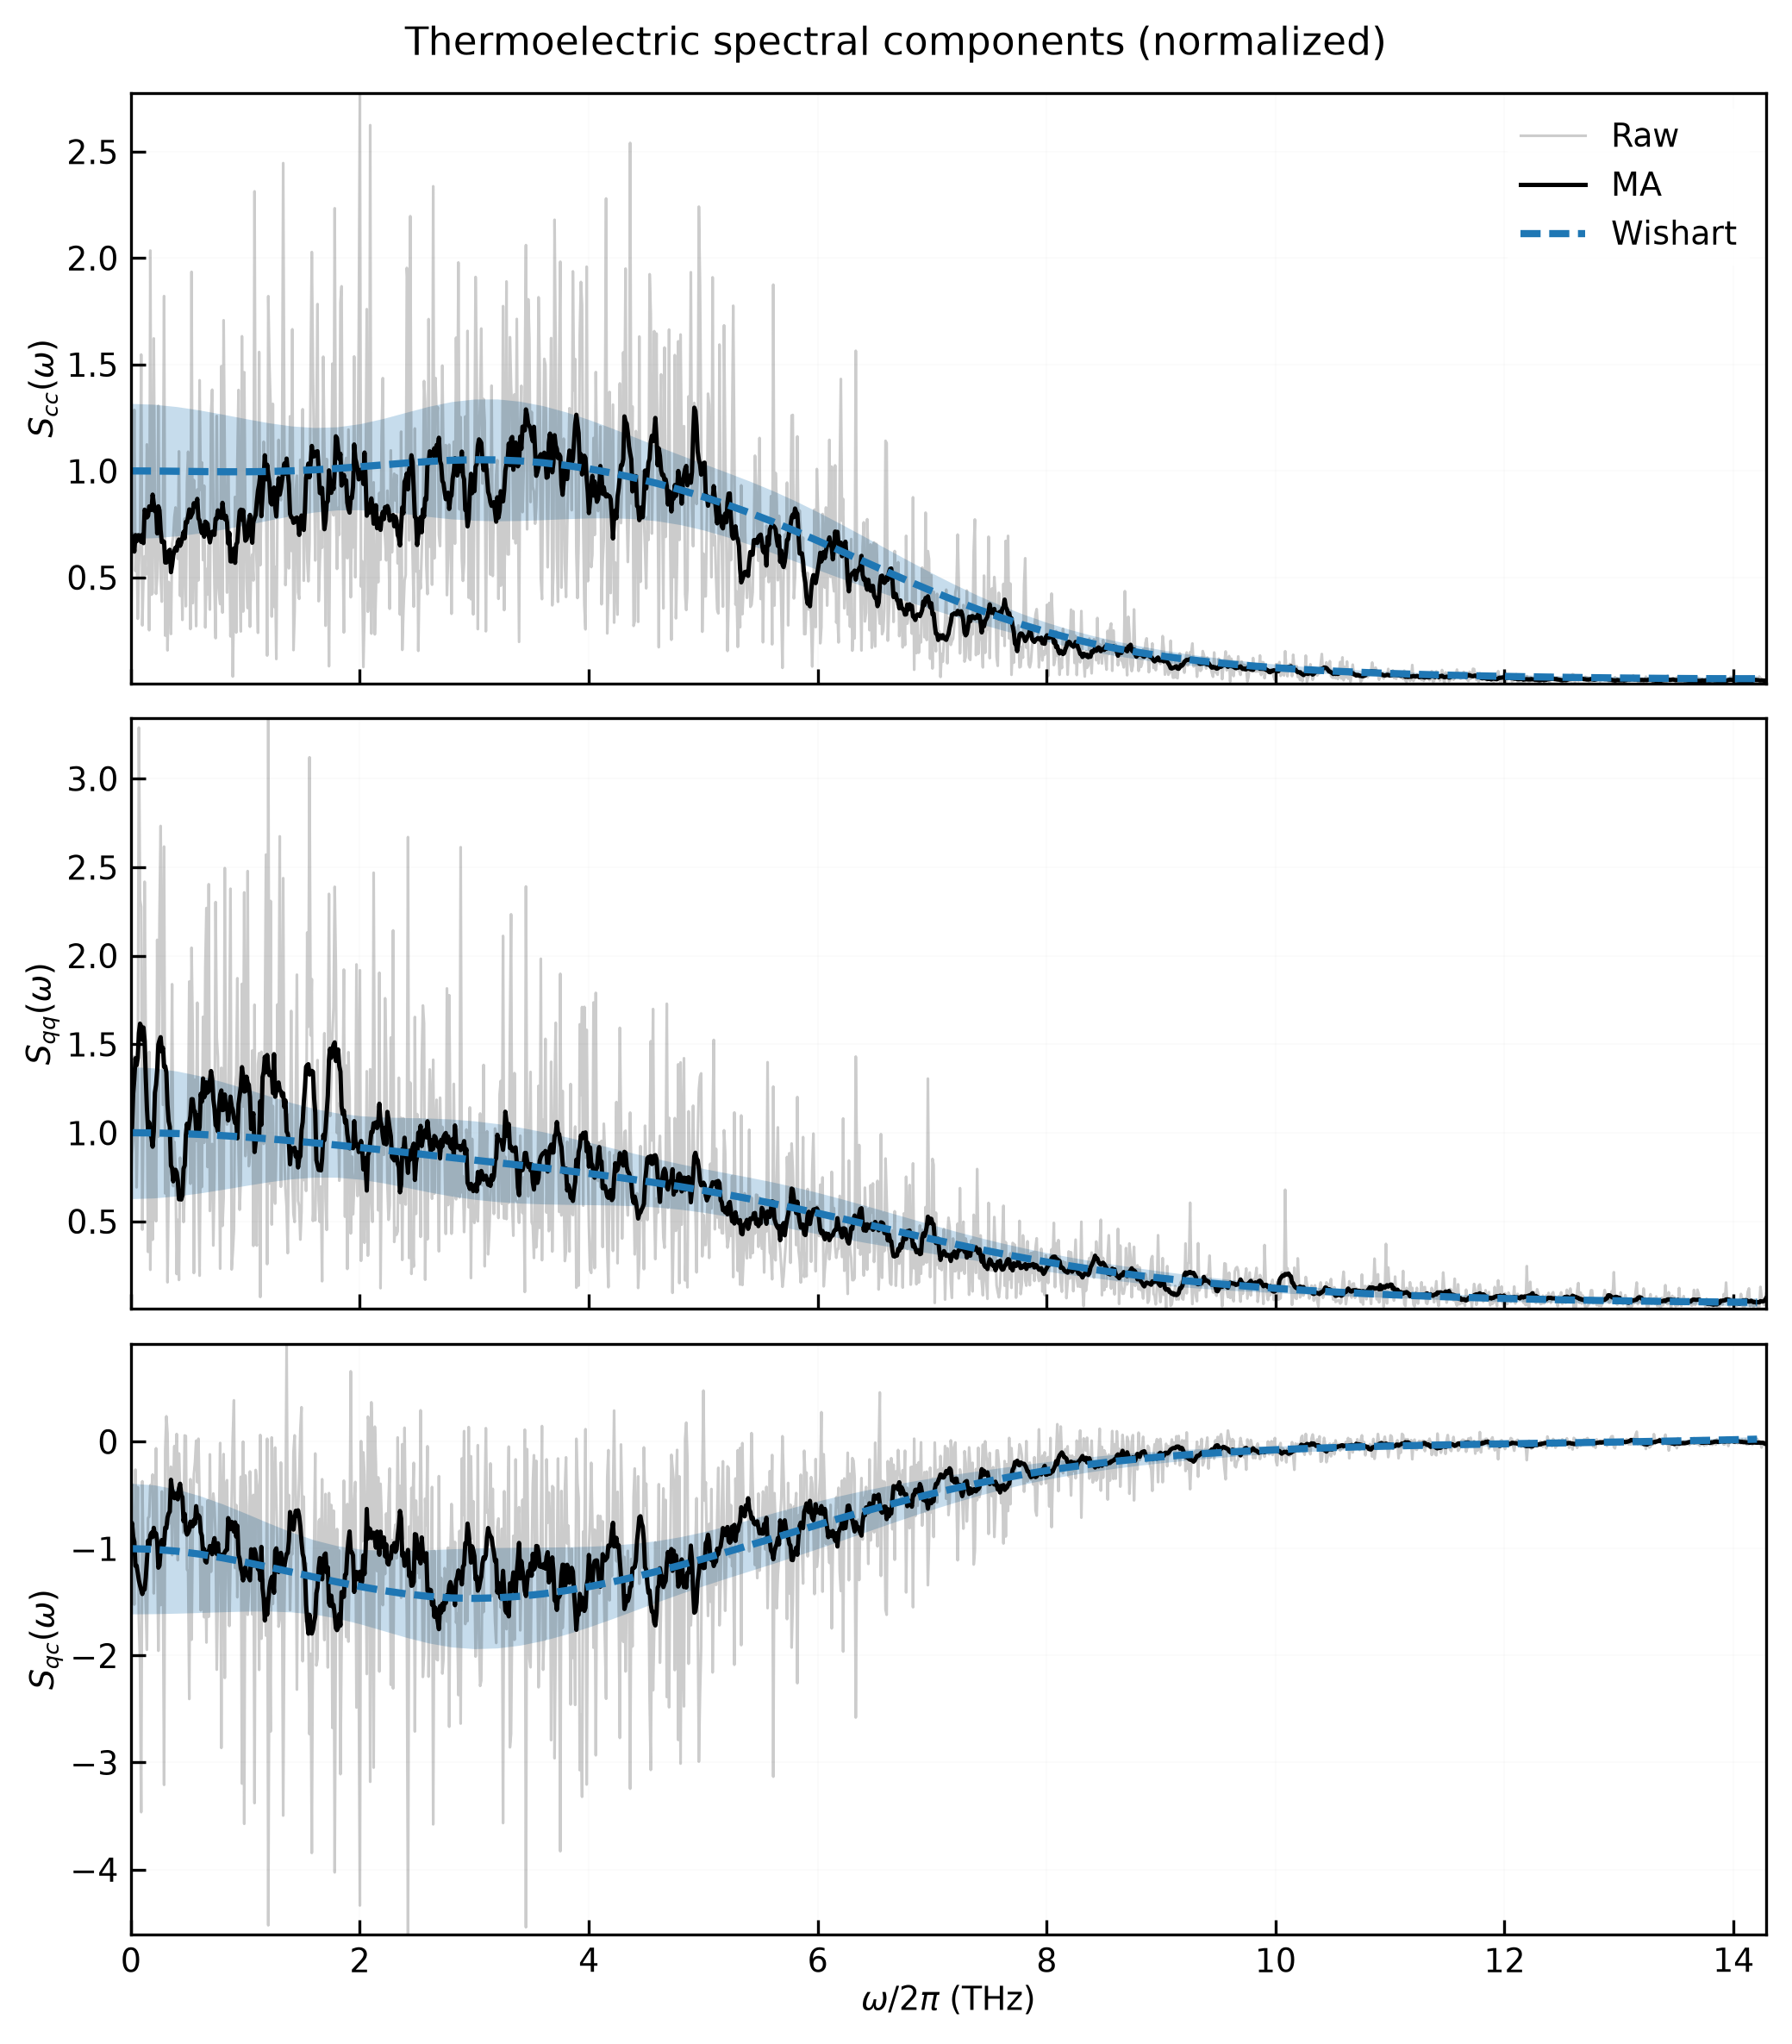

In [6]:
# 5) Plot matrix elements: raw / MA / Wishart (normalized like workflow diagnostics)
fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
components = [
    (1, 1, r'$S_{cc}(\omega)$'),
    (0, 0, r'$S_{qq}(\omega)$'),
    (0, 1, r'$S_{qc}(\omega)$'),
]

for ax, (i, j, label) in zip(axes, components):
    norm = max(abs(fit_S[0, i, j]), 1e-12)

    ax.plot(freq_raw, raw_S[:, i, j] / norm, color='k', alpha=0.2, label='Raw')
    ax.plot(freq_raw, filt_S[:, i, j] / norm, color='k', lw=1.2, label='MA')

    y = fit_S[:, i, j] / norm
    ax.plot(freq_fit, y, color='tab:blue', ls='--', lw=2.0, label='Wishart')

    if fit_S_std is not None:
        y_std = fit_S_std[:, i, j] / norm
        ax.fill_between(freq_fit, y - y_std, y + y_std, color='tab:blue', alpha=0.25)

    ax.set_ylabel(label)
    ax.grid(alpha=0.2)

axes[0].legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel(r'$\omega/2\pi$ (THz)')
fig.suptitle('Thermoelectric spectral components (normalized)')
fig.tight_layout()

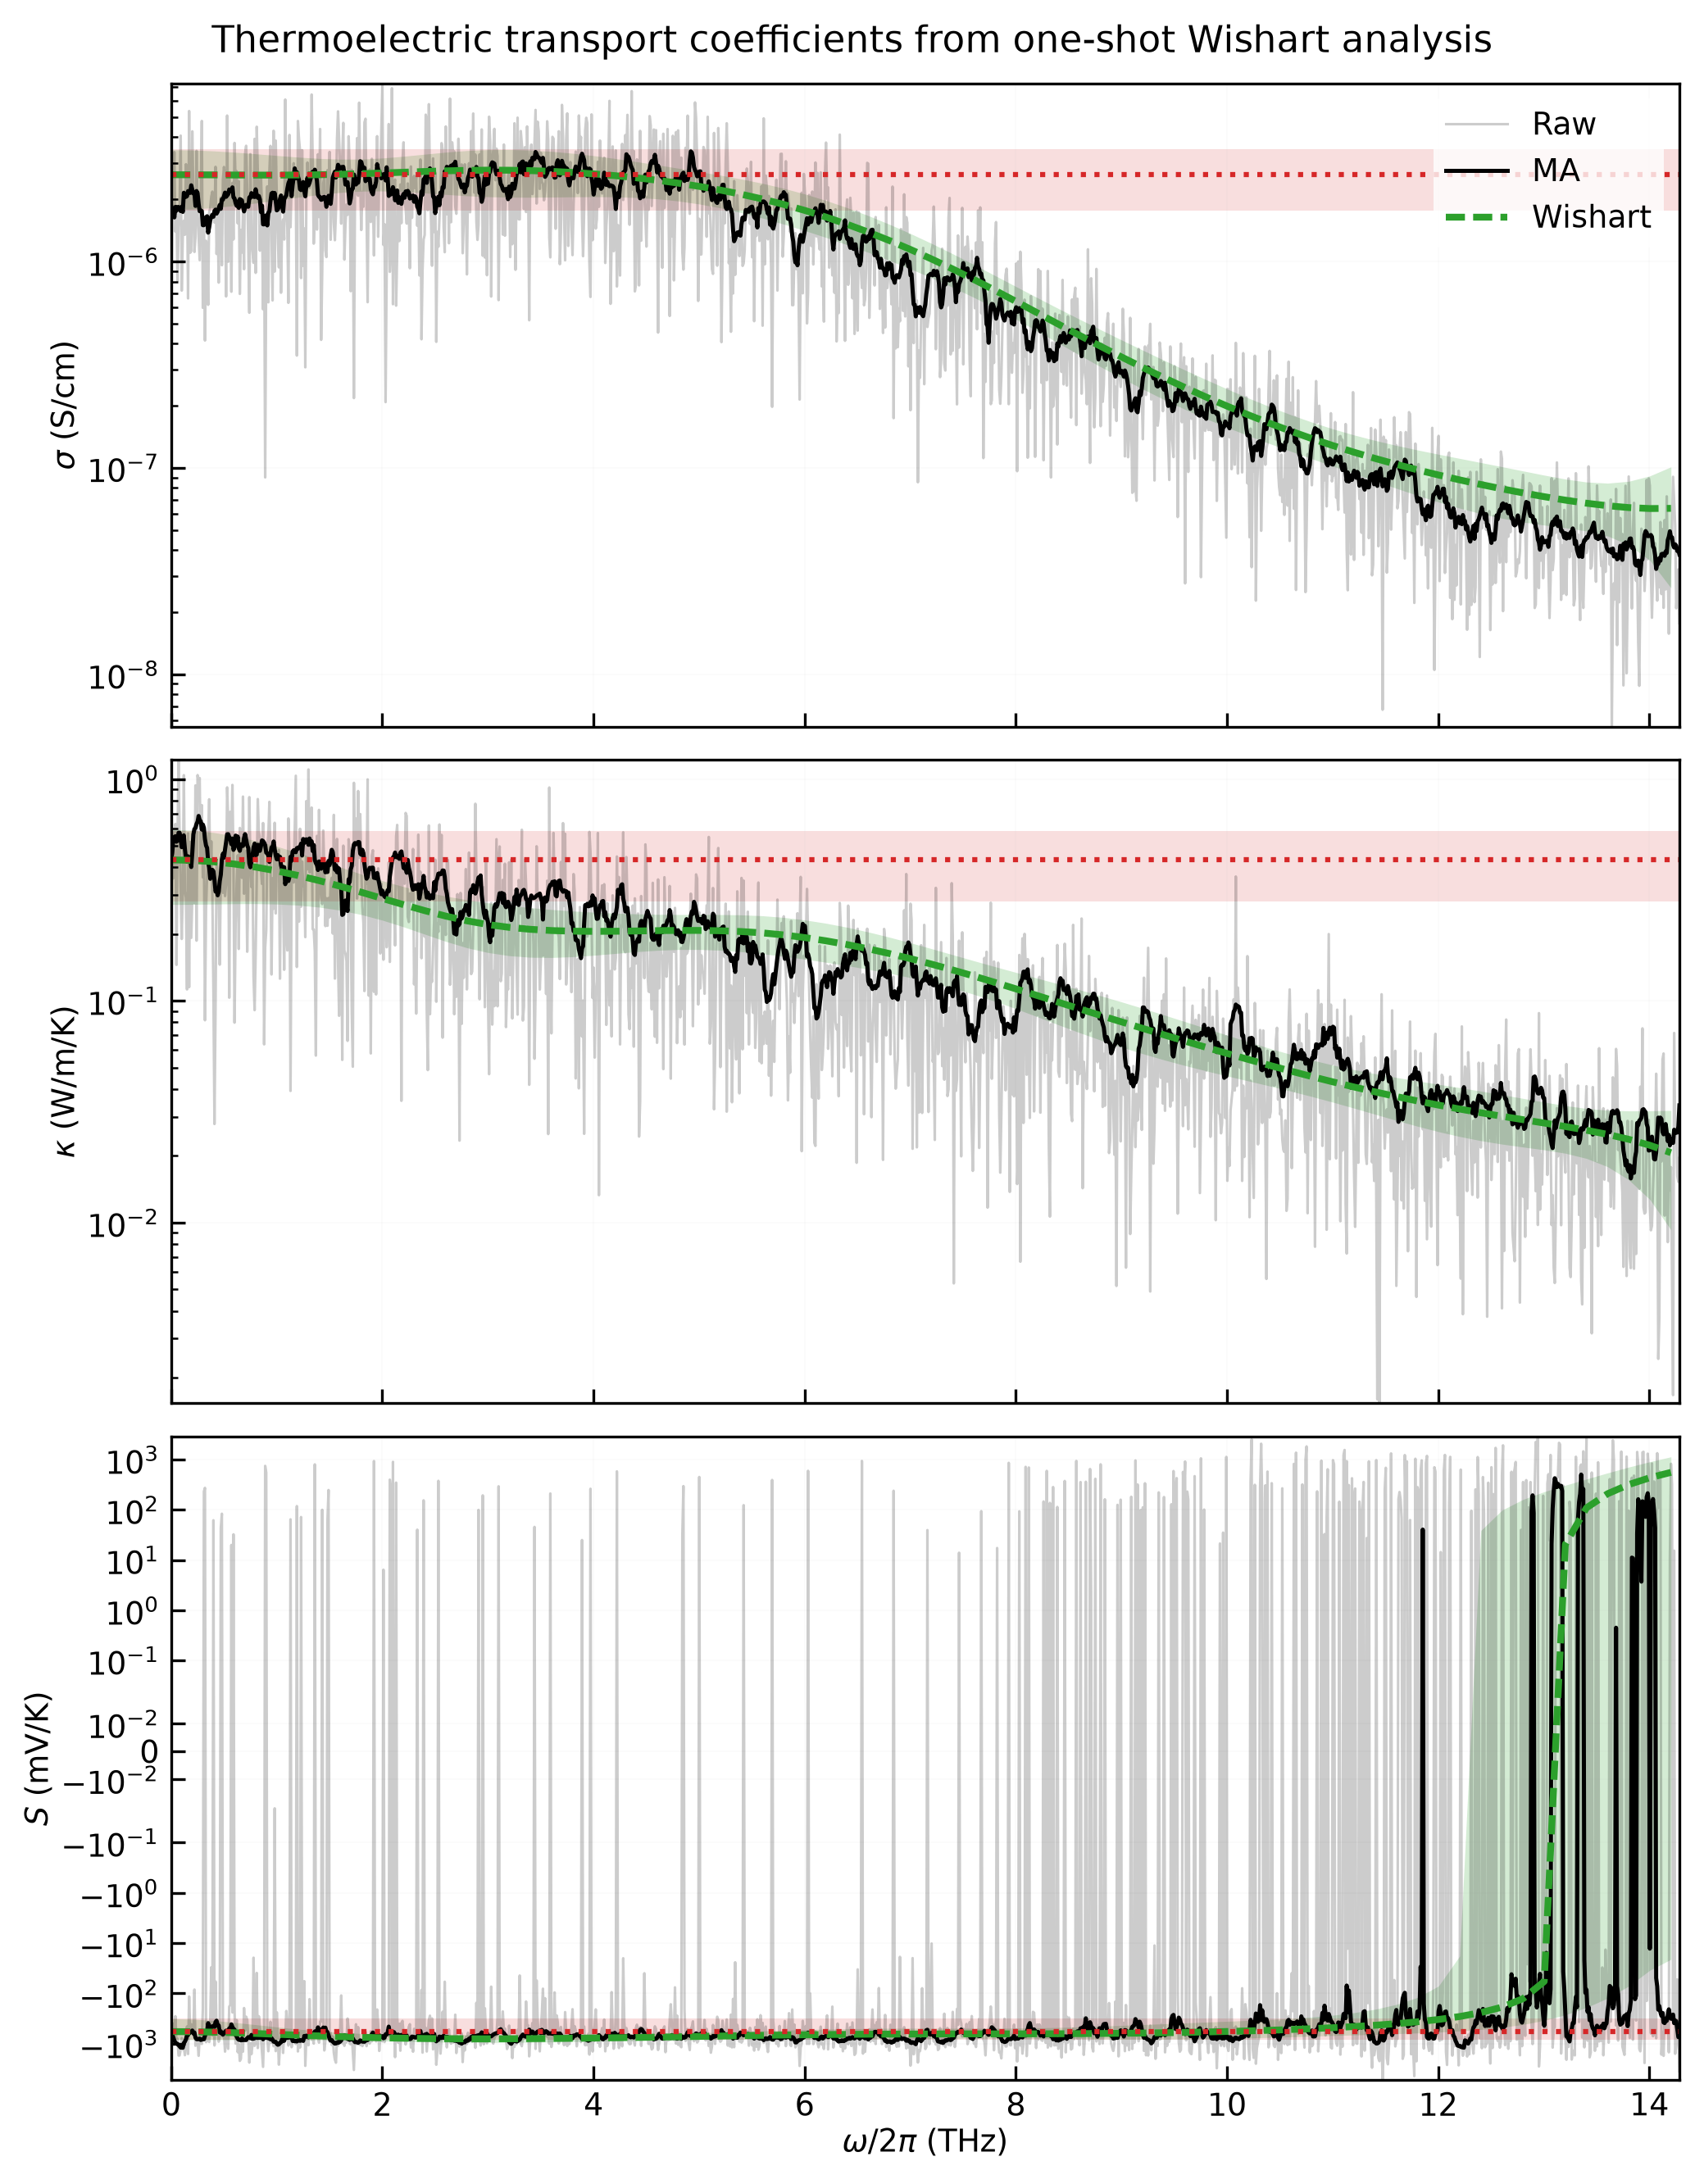

In [7]:
# 6) Plot derived coefficients vs frequency: raw / MA / Wishart
fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

panels = [
    (axes[0], sigma_raw, sigma_filt, sigma_fit, sigma_fit_std, result.sigma / 100.0, result.sigma_std / 100.0, r'$\sigma$ (S/cm)'),
    (axes[1], kappa_raw, kappa_filt, kappa_fit, kappa_fit_std, result.kappa, result.kappa_std, r'$\kappa$ (W/m/K)'),
    (axes[2], seeb_raw, seeb_filt, seeb_fit, seeb_fit_std, result.seebeck * 1e3, result.seebeck_std * 1e3, r'$S$ (mV/K)'),
]

for ax, y_raw, y_ma, y_fit, y_fit_std, y0, y0_std, ylabel in panels:
    ax.plot(freq_raw, y_raw, color='k', alpha=0.2, label='Raw')
    ax.plot(freq_raw, y_ma, color='k', lw=1.2, label='MA')
    ax.plot(freq_fit, y_fit, color='tab:green', lw=2.0, ls='--', label='Wishart')
    if y_fit_std is not None:
        ax.fill_between(freq_fit, y_fit - y_fit_std, y_fit + y_fit_std, color='tab:green', alpha=0.2)

    ax.axhline(y0, color='tab:red', lw=1.5, ls=':')
    if y0_std is not None:
        ax.axhspan(y0 - y0_std, y0 + y0_std, color='tab:red', alpha=0.15)

    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)

axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[2].set_yscale('symlog', linthresh=0.02)

axes[0].legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel(r'$\omega/2\pi$ (THz)')
fig.suptitle('Thermoelectric transport coefficients from one-shot Wishart analysis')
fig.tight_layout()